# Quantum Computing Lab - Assignment 1
## Mrudula A Mahindrakar
## EE25S011

In [ ]:
!pip install "qiskit>=2.1.0" "qiskit-aer>=0.17.0" "qiskit-ibm-runtime>=0.40.1" numpy pylatexenc

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.visualization import plot_histogram, plot_state_city, plot_bloch_multivector
from qiskit.quantum_info import Statevector, DensityMatrix, Operator, state_fidelity

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np
from IPython.display import display


In [ ]:
!pip install qiskit-experiments

In [2]:
from qiskit_experiments.library import StateTomography

# Optional: configure IBM Quantum
QiskitRuntimeService.save_account(
token="", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="", # Optional: Use the CRN you created and saved from the IBM Quantum Platform Home dashboard
channel="ibm_cloud", # Optional: Use "ibm_quantum" for public access or "ibm_quantum_private" for private access
overwrite=True # Optional: Overwrite existing saved accounts
)

service = QiskitRuntimeService(channel="ibm_cloud")
print(service.backends())  # list available backends

# Example to select a backend (modify as needed)
backend = service.backend("ibm_torino")  # or any other available backend

sim_backend = AerSimulator() # Use simulator by default

[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


## Problem 1 – Using Quantum Circuits on IBM Q

Using quantum circuits on IBM Q (or a simulator), you are asked to verify:

1. The **Fredkin gate** (controlled‑SWAP) is self‑inverse.  
2. The following identities, where $C$ is the CNOT with qubit 1 as control and qubit 2 as target, and $X_1$ denotes $X$ acting on qubit 1, etc.:

**(a) Fredkin gate self-inverse:** Show that $CSWAP \cdot CSWAP = I$

**(b) CX₁C = X₁X₂:** Verify CNOT-X identity (C is CNOT with control=1, target=2)

**(c) CZ₁C = Z₁:** Verify CZ-identity

**(d) CY₂C = Z₁Y₂:** Verify CY-identity

**(e) CY₁C = Y₁X₂:** Verify another CY-identity

### Problem 1a

To verify that **Fredkin** gate is **self‑inverse**:

1. We construct a circuit implementing the Fredkin gate using built‑in `cswap`.  
2. Compose the gate with itself and compare the resulting unitary or statevector on a set of input basis states.  
3. Show that applying the gate twice gives back the original state (up to global phase).


In [15]:
# Problem 1a Veryfing that the fredkin gate is self inverse.

qc_fredkin = QuantumCircuit(3, name="Fredkin")
qc_fredkin.cswap(0, 1, 2)

fredkin_gate = qc_fredkin.to_gate(label="Fredkin")

qc_test = QuantumCircuit(3)
qc_test.append(fredkin_gate, [0, 1, 2])
qc_test.append(fredkin_gate, [0, 1, 2])

for i in range(8):
    sv = Statevector.from_int(i, dims=(2,2,2))
    
    # apply Fredkin twice
    sv_out = sv.evolve(qc_test)
    
    # compare
    if not sv_out.equiv(sv):
        print("Mismatch at state |{:03b}>".format(i))
        break
else:
    print("CSWAP . CSWAP = Identity is verified for all basis states.")
    print("Fredkin is self-inverse.")

CSWAP . CSWAP = Identity is verified for all basis states.
Fredkin is self-inverse.


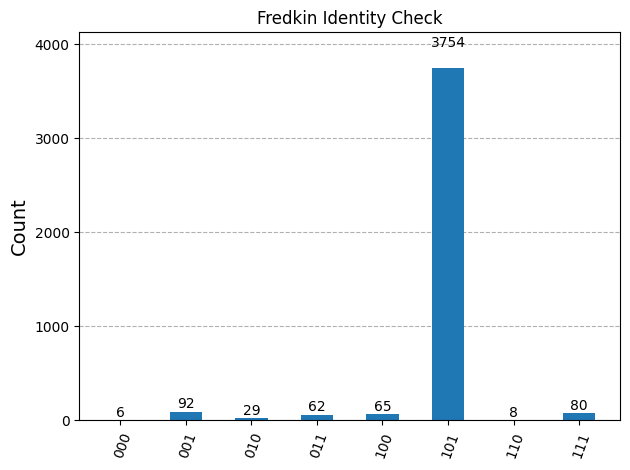

In [59]:
# Verification on IBMQ 
# We test the fredkin gate for a specific state, ex. 101

qc_id = QuantumCircuit(3)
qc_id.x(0)
qc_id.x(2)

# Apply Fredkin twice
qc_id.cswap(0, 1, 2)
qc_id.cswap(0, 1, 2)

qc_id.measure_all()

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_qc = pm.run(qc_id)

sampler = Sampler(backend)
job = sampler.run([isa_qc])
result = job.result()

pub_result = result[0]
counts = pub_result.data.meas.get_counts()
display(plot_histogram(counts, title="Fredkin Identity Check"))

### For problems 1b,1c,1d,1e
To verify the following equalities using circuits:

- $C X_1 C = X_1 X_2$ 
- $C Z_1 C = Z_1$
- $C Y_2 C = Z_1 Y_2$
- $C Y_1 C = Y_1 X_2$

We will,

1. Build a circuit that applies $C$, then the single‑qubit gate(s), then $C$ again.  
2. Build a second circuit that applies only the purported equivalent gate sequence on the same qubits.  
3. Compare the statevectors for all 4 basis inputs $\vert 00\rangle, \vert 01\rangle, \vert 10\rangle, \vert 11\rangle$.

### General Approach for Verification

To verify an identity like $UVU = W$:

1. **Create two circuits:**
   - Left-hand side: Apply U, then V, then U
   - Right-hand side: Apply W

2. **For each input basis state** (|00⟩, |01⟩, |10⟩, |11⟩):
   - Prepare input state
   - Apply LHS circuit
   - Apply RHS circuit to same initial state
   - Measure and compare statistics

3. **Verification:** If measurement distributions are identical, the identity holds

### Alternative: Direct Statevector Comparison

Use statevector simulation to get exact quantum states and compare amplitudes:

```python
sv_lhs = Statevector.from_instruction(lhs_circuit)
sv_rhs = Statevector.from_instruction(rhs_circuit)
fidelity = state_fidelity(sv_lhs, sv_rhs)  # Should be ≈ 1.0
```

In [61]:
def build_cac_circuit(single_qubit_op, target_qubit, label):
    qc = QuantumCircuit(2, name=label)
    qc.cx(0, 1)
    single_qubit_op(qc, target_qubit)
    qc.cx(0, 1)
    return qc

def build_rhs_circuit(op_sequence, label):
    qc = QuantumCircuit(2, name=label)
    op_sequence(qc)
    return qc

def compare_two_circuits(qc1, qc2, label):
    check = True
    
    for basis in range(4):
        sv_in = Statevector.from_int(basis, 4)
        
        sv1 = sv_in.evolve(qc1)
        sv2 = sv_in.evolve(qc2)

        if not sv1.equiv(sv2):
            print(f"Mismatch for basis |{basis:02b}⟩")
            break
    
    else:
        print(f"{label} is verified.")


In [69]:
# Problem 1b
def single_op_X1(qc, target):
    qc.x(0)

def rhs_X1X2(qc):
    qc.x(0)
    qc.x(1)

qc_left1b = build_cac_circuit(single_op_X1, 0, "C-X1-C")
qc_right1b = build_rhs_circuit(rhs_X1X2, "X1-X2")

compare_two_circuits(qc_left1b, qc_right1b,"C-X1-C = X1-X2")

C-X1-C = X1-X2 is verified.


In [70]:
# Problem 1c
def single_op_Z1(qc, target):
    qc.z(0)

def rhs_Z1(qc):
    qc.z(0)

qc_left1c = build_cac_circuit(single_op_Z1, 0, "C-Z1-C")
qc_right1c = build_rhs_circuit(rhs_Z1, "rhs-c")

compare_two_circuits(qc_left1c, qc_right1c, "C-Z1-C = Z1")


C-Z1-C = Z1 is verified.


In [65]:
# Problem 1d
def single_op_Y2(qc, target):
    qc.y(1)

def rhs_Z1Y2(qc):
    qc.z(0)
    qc.y(1)

qc_left1d = build_cac_circuit(single_op_Y2, 1, "C-Y2-C")
qc_right1d = build_rhs_circuit(rhs_Z1Y2, "Z1-Y2")

compare_two_circuits(qc_left1d, qc_right1d, "C-Y2-C = Z1-Y2")


C-Y2-C = Z1-Y2 is verified.


In [71]:
# Problem 1c
def single_op_Y1(qc, target):
    qc.y(0)

def rhs_Y1X2(qc):
    qc.y(0)
    qc.x(1)

qc_left1e = build_cac_circuit(single_op_Y1, 0, "C-Y1-C")
qc_right1e = build_rhs_circuit(rhs_Y1X2, "Y1-X2")

compare_two_circuits(qc_left1e, qc_right1e, "C-Y1-C = Y1-X2")


C-Y1-C = Y1-X2 is verified.


In [ ]:
# verification on IBM Q machines
sampler = Sampler(backend)

def IBMQ_verification(qc_lhs, qc_rhs, initial_state_indices=[0, 1, 2, 3]):
    all_results = []
    
    for idx in initial_state_indices:
        # Create a state ex. |01> 
        test_lhs = QuantumCircuit(2)
        if idx & 1: 
            test_lhs.x(0)
        if idx & 2: 
            test_lhs.x(1)
        test_lhs.compose(qc_lhs, inplace=True)
        test_lhs.measure_all()
        
        test_rhs = QuantumCircuit(2)
        if idx & 1: 
            test_rhs.x(0)
        if idx & 2: 
            test_rhs.x(1)
        test_rhs.compose(qc_rhs, inplace=True)
        test_rhs.measure_all()
        
        pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
        isa_lhs = pm.run(test_lhs)
        isa_rhs = pm.run(test_rhs)
        
        job = sampler.run([isa_lhs, isa_rhs])
        result = job.result()
        
        counts_lhs = result[0].data.meas.get_counts()
        counts_rhs = result[1].data.meas.get_counts()
        all_results.append((counts_lhs, counts_rhs))
        
    return all_results

results_1b = IBMQ_verification(qc_left1b, qc_right1b)
results_1c = IBMQ_verification(qc_left1c, qc_right1c)
results_1d = IBMQ_verification(qc_left1d, qc_right1d)
results_1e = IBMQ_verification(qc_left1e, qc_right1e)

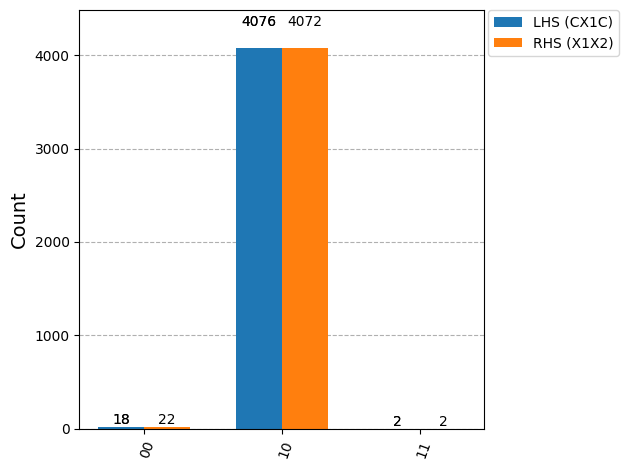

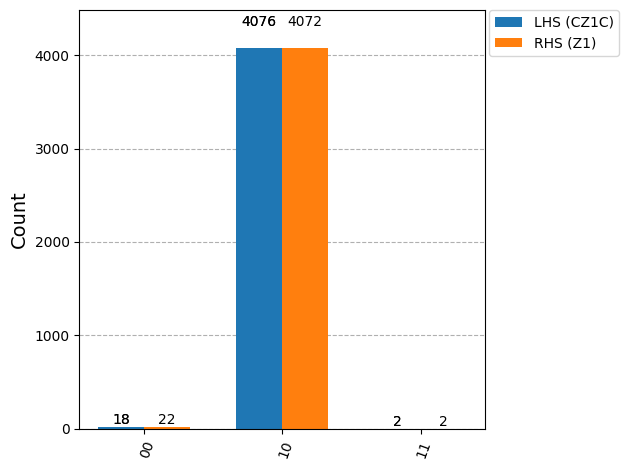

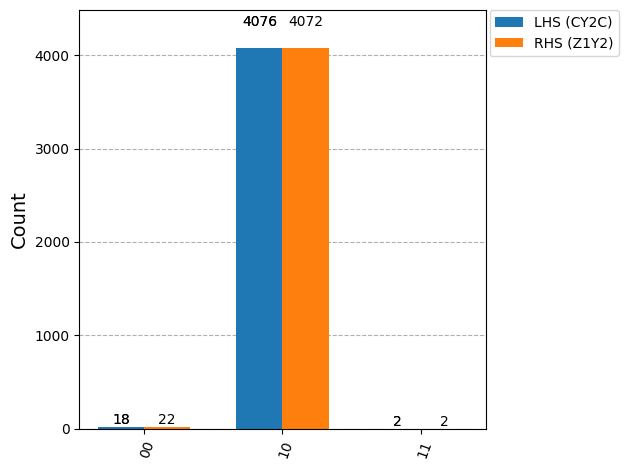

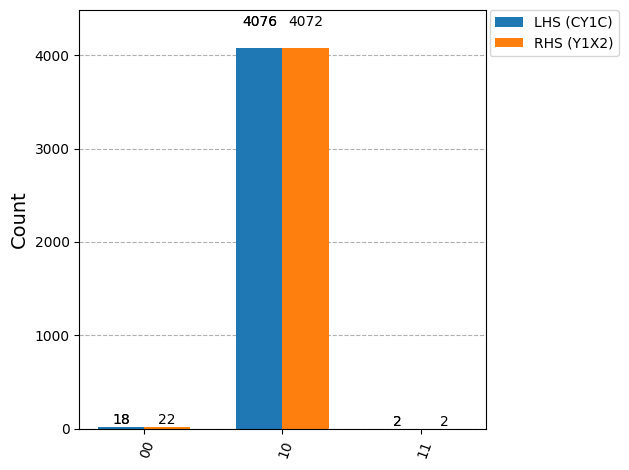

In [73]:
l_counts1b, r_counts1b = results_1b[1] # For initial state |01>
display(plot_histogram([l_counts1b, r_counts1b], legend=['LHS (CX1C)', 'RHS (X1X2)']))

l_counts1b, r_counts1b = results_1b[1] # For initial state |01>
display(plot_histogram([l_counts1b, r_counts1b], legend=['LHS (CZ1C)', 'RHS (Z1)']))

l_counts1b, r_counts1b = results_1b[1] # For initial state |01>
display(plot_histogram([l_counts1b, r_counts1b], legend=['LHS (CY2C)', 'RHS (Z1Y2)']))

l_counts1b, r_counts1b = results_1b[1] # For initial state |01>
display(plot_histogram([l_counts1b, r_counts1b], legend=['LHS (CY1C)', 'RHS (Y1X2)']))

## Problem 2 – GHZ states

A **GHZ state** for \(N\) qubits is

$\vert \text{GHZ}_N \rangle = \frac{1}{\sqrt{2}} \big( \vert 0\ldots 0 \rangle + \vert 1\ldots 1 \rangle \big)$.

We prepare $\vert \text{GHZ}_N \rangle$ by:

1. Start from $\vert 0\ldots 0 \rangle$.  
2. Apply a Hadamard gate \(H\) to the first qubit to create

$\frac{1}{\sqrt{2}} (\vert 0 \rangle + \vert 1 \rangle)\vert 0\ldots 0 \rangle.$

3. Apply a series of CNOT gates from the first qubit to each of the remaining \(N-1\) qubits, entangling them to produce the GHZ state.

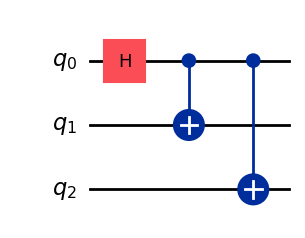

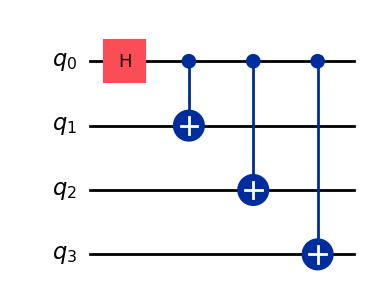

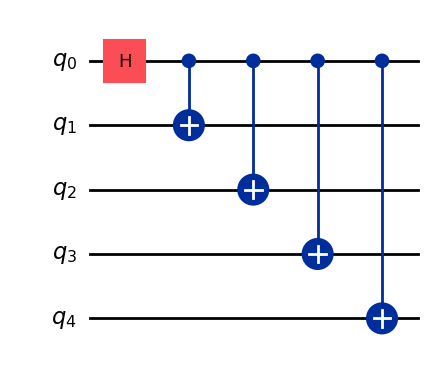

In [4]:
def ghz_circuit(n_qubits: int):
    qc = QuantumCircuit(n_qubits, name=f"GHZ_{n_qubits}")
    qc.h(0)
    for i in range(1, n_qubits):
        qc.cx(0, i)
    return qc

qc_ghz3 = ghz_circuit(3)
qc_ghz4 = ghz_circuit(4)
qc_ghz5 = ghz_circuit(5)

display(qc_ghz3.draw("mpl"))
display(qc_ghz4.draw("mpl"))
display(qc_ghz5.draw("mpl"))

In [5]:
sv3 = Statevector.from_instruction(qc_ghz3)
sv4 = Statevector.from_instruction(qc_ghz4)
sv5 = Statevector.from_instruction(qc_ghz5)

print("GHZ 3 qubit:\n", sv3)
print("\n GHZ 4 qubit:\n", sv4)
print("\n GHZ 5 qubit:\n", sv5)

GHZ 3 qubit:
 Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))

 GHZ 4 qubit:
 Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2, 2, 2))

 GHZ 5 qubit:
 Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.

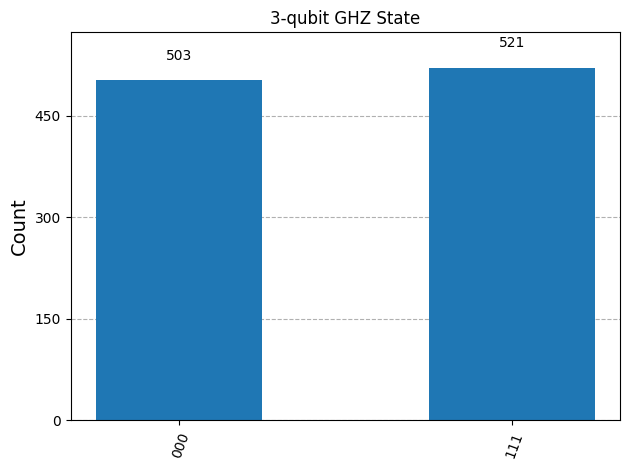

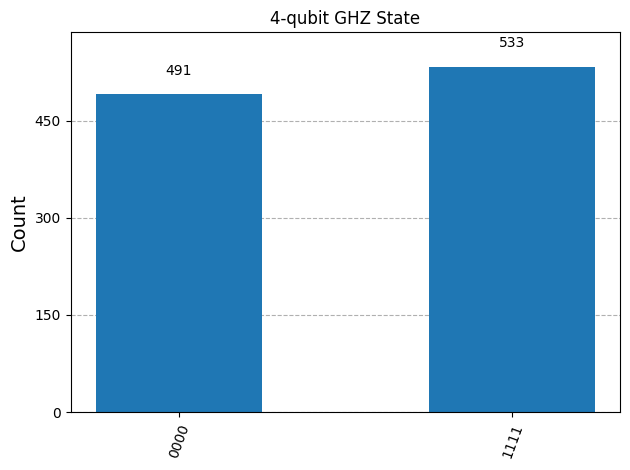

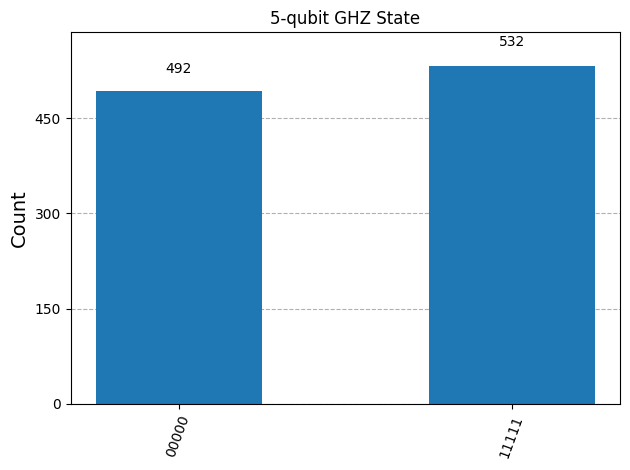

In [6]:
# verification using Simulator

def run_simulation(qc):
    qc_m = qc.copy()
    qc_m.measure_all()
    
    backend = Aer.get_backend("aer_simulator")
    result = backend.run(qc_m, shots=1024).result()
    counts = result.get_counts()
    
    return counts

counts3 = run_simulation(qc_ghz3)
counts4 = run_simulation(qc_ghz4)
counts5 = run_simulation(qc_ghz5)

display(plot_histogram(counts3, title="3-qubit GHZ State"))
display(plot_histogram(counts4, title="4-qubit GHZ State"))
display(plot_histogram(counts5, title="5-qubit GHZ State"))

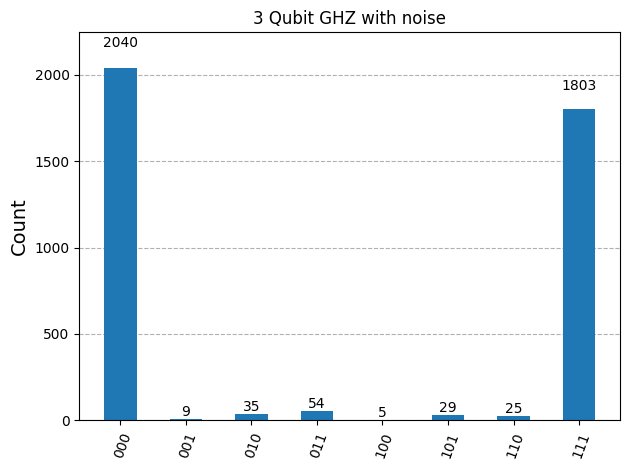

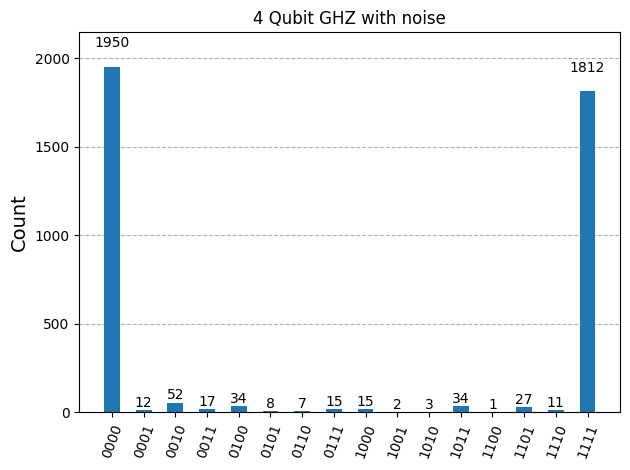

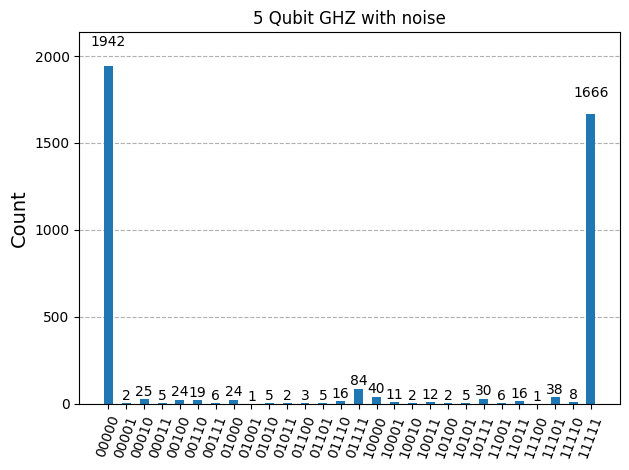

In [12]:
# verification using IBM Q Machine

def IBMQ_verification(qc):
    qc_m = qc.copy()
    qc_m.measure_all()
    
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    isa_qc = pm.run(qc_m)
    
    
    sampler = Sampler(backend)
    job = sampler.run([isa_qc], shots=4000)
    
    result = job.result()
    pub_result = result[0]
    
    register_name = list(pub_result.data.keys())[0]
    counts = pub_result.data[register_name].get_counts()
    
    return counts

counts1 = IBMQ_verification(qc_ghz3)
counts2 = IBMQ_verification(qc_ghz4)
counts3 = IBMQ_verification(qc_ghz5)

display(plot_histogram(counts1, title=f"3 Qubit GHZ with noise"))
display(plot_histogram(counts2, title=f"4 Qubit GHZ with noise"))
display(plot_histogram(counts3, title=f"5 Qubit GHZ with noise"))

## Problem 3 – Preparation of specific 3-qubit states

To prepare the states:

1. $\frac{1}{\sqrt{2}}(\vert 001\rangle + \vert 110\rangle)$  
2. $\frac{1}{\sqrt{2}}(\vert 101\rangle + \vert 010\rangle)$
3. $\frac{1}{\sqrt{2}}(\vert 100\rangle + \vert 011\rangle)$

General strategy:

- Construct a GHZ state
- Apply the appropriate Pauli operator on the required qubits to obtain the required state.


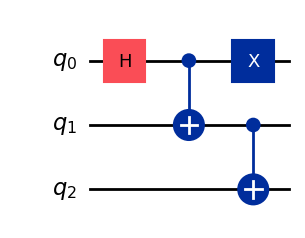

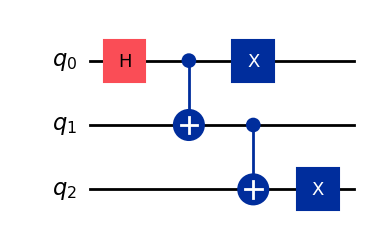

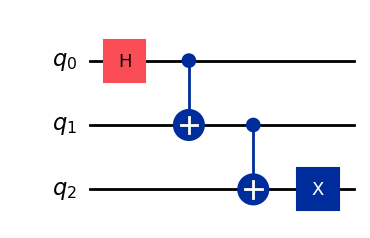

In [8]:
def ghz_circuit():
    qc = QuantumCircuit(3, name="GHZ")
    qc.h(0)        
    qc.cx(0, 1)
    qc.cx(1, 2)
    return qc

def state_1():
    qc = ghz_circuit()
    qc.x(0)
    return qc
    
def state_2():
    qc = ghz_circuit()
    qc.x(2)
    qc.x(0)
    return qc

def state_3():
    qc = ghz_circuit()
    qc.x(2)
    return qc

qc_psi1 = state_1()
qc_psi2 = state_2()
qc_psi3 = state_3()

display(qc_psi1.draw("mpl"))
display(qc_psi2.draw("mpl"))
display(qc_psi3.draw("mpl"))

In [9]:
sv1 = Statevector.from_instruction(state_1())
sv2 = Statevector.from_instruction(state_2())
sv3 = Statevector.from_instruction(state_3())

print(sv1)
print("The statevector has non-zero, equal amplitudes at indices 1 and 6, indictating the qubits 001 and 110 have been prepared \n")
print(sv2)
print("The statevector has non-zero, equal amplitudes at indices 2 and 5, indictating the qubits 101 and 010 have been prepared \n")
print(sv3)
print("The statevector has non-zero, equal amplitudes at indices 3 and 4, indictating the qubits 100 and 011 have been prepared")

Statevector([0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j, 0.        +0.j],
            dims=(2, 2, 2))
The statevector has non-zero, equal amplitudes at indices 1 and 6, indictating the qubits 001 and 110 have been prepared 

Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))
The statevector has non-zero, equal amplitudes at indices 2 and 5, indictating the qubits 101 and 010 have been prepared 

Statevector([0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))
The statevector has non-zero, equal amplitudes at indices 3 and 4, indictating the qubits 100 and 011 have been prepared


## Problem 4 – W states and tomography

A multipartite entangled state with equal amplitude:

The standard 3-qubit W state is

$\vert W_3 \rangle = \frac{1}{\sqrt{3}}(\vert 001\rangle + \vert 010\rangle + \vert 100\rangle)$.

For a 4-qubit system, a *W-like* state is

$\vert W_4 \rangle = \frac{1}{2}(\vert 0001\rangle + \vert 0010\rangle + \vert 0100\rangle + \vert 1000\rangle).$

1. Construct circuits that prepare these states.  
2. Verify their output via **quantum state tomography** on any IBMQ machine.

In [76]:
from qiskit.circuit.library import CHGate

def w3_circuit():
    qc = QuantumCircuit(3, name="W3")

    phi3 = 2 * np.arccos(1 / np.sqrt(3)) # 2 arccos(1/root(3))
    
    # Ry gate
    qc.ry(phi3, 0)

    # Controlled-H gate
    qc.append(CHGate(), [0, 1])

    qc.cx(1, 2)
    qc.cx(0, 1)

    qc.x(0)

    return qc

def w4_circuit():
    qc = QuantumCircuit(4, name="W4")

    # Ry gate
    phi4 = 2 * np.arccos(1 / np.sqrt(4))  # 2 arccos(1/2)
    qc.ry(phi4, 0)

    # controlled-W3 gate 
    w3_gate = w3_circuit().to_gate(label="W3")
    controlled_w3 = w3_gate.control(1)

    qc.append(controlled_w3, [0, 1, 2, 3])

    qc.x(0)

    return qc

sv_w3 = Statevector.from_instruction(w3_circuit())
sv_w4 = Statevector.from_instruction(w4_circuit())

print("W3 statevector:\n", sv_w3,"\n")
print("W4 statevector:\n", sv_w4)

W3 statevector:
 Statevector([0.        +0.j, 0.57735027+0.j, 0.57735027+0.j,
             0.        +0.j, 0.57735027+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2)) 

W4 statevector:
 Statevector([0.00000000e+00+0.00000000e+00j,
             5.00000000e-01+0.00000000e+00j,
             5.00000000e-01+0.00000000e+00j,
             0.00000000e+00+0.00000000e+00j,
             5.00000000e-01-1.11855716e-17j,
             0.00000000e+00-1.29564835e-16j,
             0.00000000e+00+0.00000000e+00j,
             0.00000000e+00+0.00000000e+00j,
             5.00000000e-01+4.18017416e-17j,
             0.00000000e+00+0.00000000e+00j,
             0.00000000e+00+0.00000000e+00j,
             0.00000000e+00+0.00000000e+00j,
             0.00000000e+00+0.00000000e+00j,
             0.00000000e+00+0.00000000e+00j,
             1.11855716e-17+3.92523115e-17j,
             0.00000000e+00+0.00000000e+00j],
            dims=(2, 2, 2, 2))


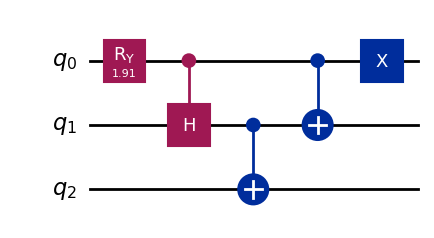

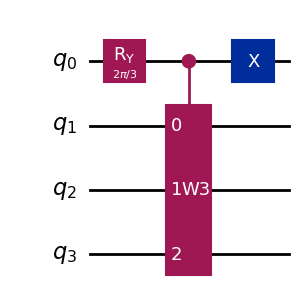

In [77]:
qc_W3 = w3_circuit()
qc_W4 = w4_circuit()

display(qc_W3.draw("mpl"))
display(qc_W4.draw("mpl"))

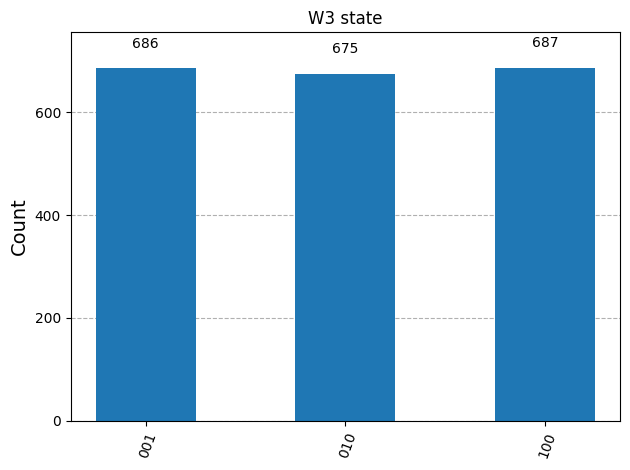

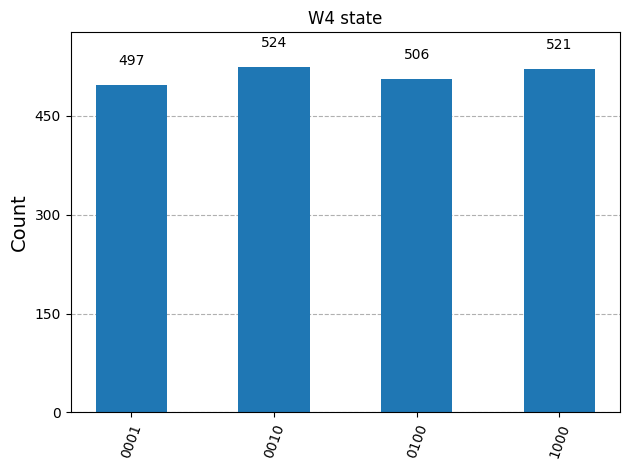

In [78]:
def run_counts(qc):
    qc_m = qc.copy()
    qc_m.measure_all()
    qc_m = qc_m.decompose(reps=5)
    backend = Aer.get_backend("aer_simulator")
    result = backend.run(qc_m, shots=2048).result()
    return result.get_counts()

display(plot_histogram(run_counts(w3_circuit()),title="W3 state"))
display(plot_histogram(run_counts(w4_circuit()),title="W4 state"))


In [53]:
# Verification using IBM Q Machines

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

qc_w3_measured = w3_circuit()
qc_w3_measured.measure_all()
isa_w3 = pm.run(qc_w3_measured)

qc_w4_measured = w4_circuit()
qc_w4_measured.measure_all()
isa_w4 = pm.run(qc_w4_measured)

target_w3 = Statevector.from_instruction(w3_circuit())
target_w4 = Statevector.from_instruction(w4_circuit())

exp_w3 = StateTomography(w3_circuit())
exp_w4 = StateTomography(w4_circuit())

job_w3 = exp_w3.run(backend)
job_w4 = exp_w4.run(backend)

data_w3 = job_w3.block_for_results()
data_w4 = job_w4.block_for_results()

rho_w3 = data_w3.analysis_results("state").value
rho_w4 = data_w4.analysis_results("state").value

fid_w3 = state_fidelity(rho_w3, target_w3)
fid_w4 = state_fidelity(rho_w4, target_w4)

print(f"W3 State Fidelity: {fid_w3:.4f}")
print(f"W4 State Fidelity: {fid_w4:.4f}")

W3 State Fidelity: 0.6991
W4 State Fidelity: 0.4683


C:\Users\mrudu\AppData\Local\Temp\ipykernel_8484\4161330398.py:25: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  rho_w3 = data_w3.analysis_results("state").value
C:\Users\mrudu\AppData\Local\Temp\ipykernel_8484\4161330398.py:26: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  rho_w4 = data_w4.analysis_results("state").value


C:\Users\mrudu\AppData\Local\Temp\ipykernel_8484\2027455558.py:1: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  hw_counts_w3 = data_w3.analysis_results("state").value.probabilities_dict()
C:\Users\mrudu\AppData\Local\Temp\ipykernel_8484\2027455558.py:2: DeprecationWarning: Leaving `dataframe` unset or setting it to `False` for `ExperimentData.analysis_results` is deprecated as of qiskit-experiments 0.9.0. Future releases may change the default to `True` and remove the option to set the value to `False`.
  hw_counts_w4 = data_w4.analysis_results("state").value.probabilities_dict()


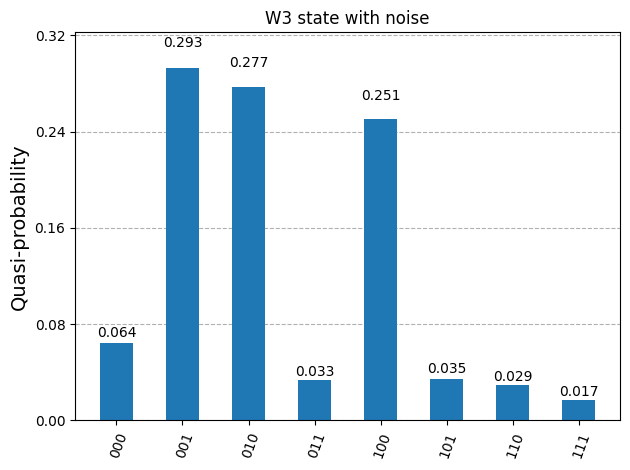

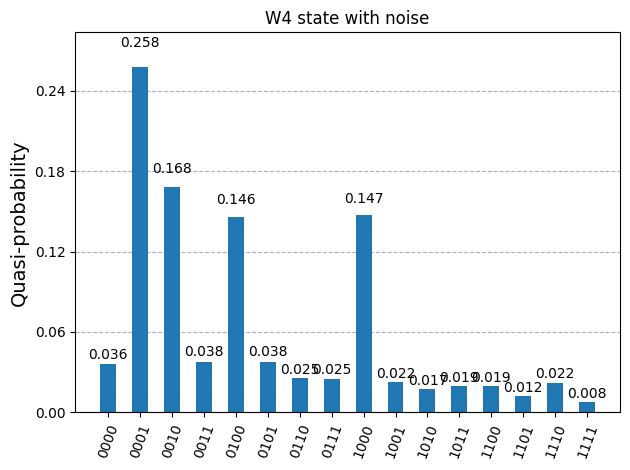

In [56]:
hw_counts_w3 = data_w3.analysis_results("state").value.probabilities_dict()
hw_counts_w4 = data_w4.analysis_results("state").value.probabilities_dict()

display(plot_histogram(hw_counts_w3, title="W3 state with noise"))

display(plot_histogram(hw_counts_w4, title="W4 state with noise"))

## Problem 5 – General N-qubit GHZ and W circuits

Given the generalized forms:

$\vert \text{GHZ}_N \rangle = \frac{1}{\sqrt{2}}(\vert 0\ldots 0\rangle + \vert 1\ldots 1\rangle)$,

$\vert W_N \rangle = \frac{1}{\sqrt{N}}(\vert 0\ldots 01\rangle + \vert 0\ldots 10\rangle + \cdots + \vert 01\ldots 0\rangle + \vert 10\ldots 0\rangle)$.

We need to **work out the quantum circuits** that prepare these families for arbitrary \(N\).


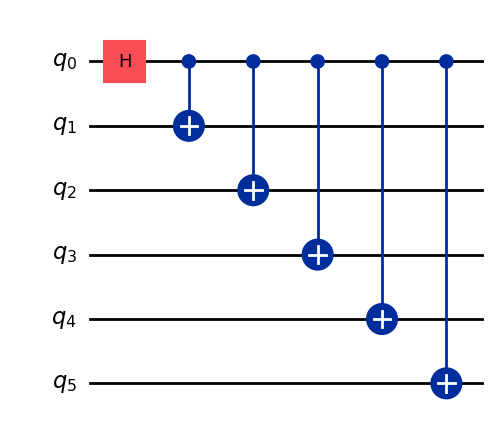

In [74]:
# Part(a) GHZ state

def ghz_general(n_qubits: int):
    qc = QuantumCircuit(n_qubits, name=f"GHZ_{n_qubits}")
    qc.h(0) 
    for i in range(1, n_qubits):
        qc.cx(0, i) 
    return qc

qc_ghz6 = ghz_general(6)
display(qc_ghz6.draw("mpl"))

In [22]:
# verification

sv_ghz = Statevector.from_instruction(qc_ghz6)
print("GHZ_6 statevector:", sv_ghz)

for basis, amp in sv_ghz.to_dict().items():
    if abs(amp) > 1e-6:
        print(basis, amp)

GHZ_6 statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
     

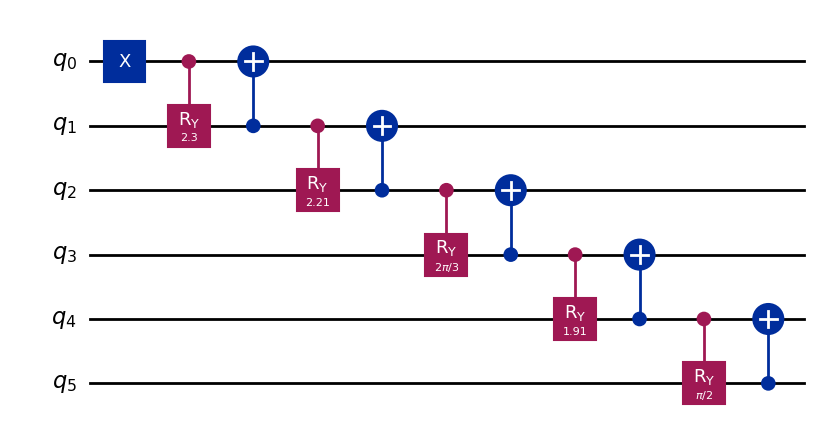

In [75]:
# Part(b) W state

def w_general(n_qubits: int):
    qc = QuantumCircuit(n_qubits, name=f"W_{n_qubits}")
    
    if n_qubits == 0: 
        return qc
    if n_qubits == 1:
        qc.x(0)
        return qc

    qc.x(0) 
    
    for i in range(n_qubits - 1):
        
        theta = 2 * np.arccos(np.sqrt(1.0 / (n_qubits - i)))
        
        # Controlled Ry gate
        qc.cry(theta, i, i + 1)
        qc.cx(i + 1, i)

    return qc

qc_w6 = w_general(6)
display(qc_w6.draw("mpl"))

In [34]:
# verification
sv_w = Statevector.from_instruction(qc_w6)
print("W_6 statevector:", sv_w)

for basis, amp in sv_w.to_dict().items():
    if abs(amp) > 1e-6:
        print(basis, amp)

W_6 statevector: Statevector([0.        +0.j, 0.40824829+0.j, 0.40824829+0.j,
             0.        +0.j, 0.40824829+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.40824829+0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.40824829+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.40824829+0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
       